In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# List the root directory of your Google Drive
print(os.listdir('/content/drive/MyDrive/'))

['Colab Notebooks', 'demonstrate.MOV', 'bear (1).stl', '无标题.obj', '无标题.mtl', '无标题.blend', 'bear.stl', 'kinect体感粒子（直接下载文件夹）.zip', '破碎重组标题深度图3.zip', 'image.jpg', 'homepage.mov', 'copy_6A490B73-D891-4CC7-BC7A-38AA68F86E60.MOV', 'c0e6cad098d36e309365b709911cd23d.jpg', 'ecfdf169dd14315dcdbc5ce92b6b966e.jpg', '131e62ea4ca6afeda74525e25dbfa112.jpg', '04b836f38496183533d447b40d963811.jpg', '2d9ae42c6736664db38eebac92e21f46.jpg', 'dji_mimo_20260330_151120_20260330151022_1774898523000_video.mov', 'dji_mimo_20260330_150832_20260330150731_1774898528278_video.mov', 'mushroom slides.png']


In [ ]:
import zipfile
import os

# Path to the zip file in your Google Drive
zip_path = '/content/drive/MyDrive/Colab Notebooks/fma_2000_tracks.zip'

# Unzip to Colab's local storage (faster than working directly from Drive)
extract_path = '/content/fma_2000_tracks'

print("Unzipping... this may take a few minutes (1.8 GB)")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Check what's inside
for root, dirs, files in os.walk(extract_path):
    # Only show first 2 levels and first 10 files
    level = root.replace(extract_path, '').count(os.sep)
    if level < 2:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        if files:
            sub_indent = ' ' * 2 * (level + 1)
            for f in files[:10]:
                print(f'{sub_indent}{f}')
            if len(files) > 10:
                print(f'{sub_indent}... and {len(files) - 10} more files')

print("\nDone!")

Unzipping... this may take a few minutes (1.8 GB)


KeyboardInterrupt: 

In [ ]:
import os

# Check the actual audio files inside
audio_path = '/content/fma_2000_tracks/fma_2000_tracks'

files = os.listdir(audio_path)
print(f"Total items: {len(files)}")
print(f"\nFirst 20 files:")
for f in sorted(files)[:20]:
    print(f"  {f}")

# Check file extensions
extensions = set(os.path.splitext(f)[1] for f in files if not f.startswith('.'))
print(f"\nFile types found: {extensions}")

In [ ]:
import os

# Check what's inside one of the numbered folders
sample_folder = '/content/fma_2000_tracks/fma_2000_tracks/000'
files = os.listdir(sample_folder)
print(f"Files in folder '000':")
for f in sorted(files):
    print(f"  {f}")

# Count total audio files across all folders
audio_path = '/content/fma_2000_tracks/fma_2000_tracks'
total_audio = 0
for folder in os.listdir(audio_path):
    folder_path = os.path.join(audio_path, folder)
    if os.path.isdir(folder_path) and not folder.startswith('.'):
        total_audio += len([f for f in os.listdir(folder_path) if f.endswith('.mp3')])

print(f"\nTotal mp3 files found: {total_audio}")

In [ ]:
# Install OpenL3 and required libraries
!pip install openl3 librosa soundfile

In [ ]:
# Install build dependencies first, then install openl3
!pip install numpy scipy resampy soundfile librosa
!pip install kapre==0.3.7
!pip install openl3 --no-build-isolation

In [ ]:
# Fix: install openl3 directly from GitHub source
!pip install "numpy<2.0"
!pip install git+https://github.com/marl/openl3.git

In [ ]:
# === PLAN B: Load OpenL3 directly from source code ===

# Step 1: Clone the openl3 source code
!git clone https://github.com/marl/openl3.git /content/openl3_src

# Step 2: Install dependencies only (skip broken openl3 setup.py)
!pip install resampy soundfile librosa "kapre==0.3.7" -q

# Step 3: Add source code to Python path (bypass pip install)
import sys
sys.path.insert(0, '/content/openl3_src')

# Step 4: Test import
import openl3
print("OpenL3 loaded successfully!")

In [ ]:
!pip install "numpy==1.26.4"

In [ ]:
import sys
sys.path.insert(0, '/content/openl3_src')

import openl3
print("OpenL3 loaded successfully!")

In [ ]:
# Re-mount Google Drive and unzip audio files
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

zip_path = '/content/drive/MyDrive/Colab Notebooks/fma_2000_tracks.zip'
extract_path = '/content/fma_2000_tracks'

if not os.path.exists(extract_path):
    print("Unzipping... please wait a few minutes")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Done!")
else:
    print("Already unzipped!")

# Count audio files
audio_root = '/content/fma_2000_tracks/fma_2000_tracks'
total = sum(1 for folder in os.listdir(audio_root)
            if os.path.isdir(os.path.join(audio_root, folder)) and not folder.startswith('.')
            for f in os.listdir(os.path.join(audio_root, folder)) if f.endswith('.mp3'))
print(f"Total mp3 files: {total}")

In [ ]:
import openl3
import librosa
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# ---- SETTINGS ----
audio_root = '/content/fma_2000_tracks/fma_2000_tracks'
SR = 22050  # sample rate

# ---- COLLECT ALL MP3 FILES ----
mp3_files = []
for folder in sorted(os.listdir(audio_root)):
    folder_path = os.path.join(audio_root, folder)
    if os.path.isdir(folder_path) and not folder.startswith('.'):
        for f in sorted(os.listdir(folder_path)):
            if f.endswith('.mp3'):
                mp3_files.append(os.path.join(folder_path, f))

print(f"Found {len(mp3_files)} mp3 files. Starting extraction...\n")

# ---- EXTRACT EMBEDDINGS ----
all_embeddings = []
track_ids = []
failed_tracks = []

for i, mp3_path in enumerate(mp3_files):
    track_id = os.path.splitext(os.path.basename(mp3_path))[0]

    try:
        # Load audio
        audio, sr = librosa.load(mp3_path, sr=SR, mono=True)

        # Skip very short audio (less than 1 second)
        if len(audio) < SR:
            failed_tracks.append(track_id)
            continue

        # Extract OpenL3 embedding (music model, 512-dim)
        emb, ts = openl3.get_audio_embedding(
            audio, sr,
            content_type="music",
            embedding_size=512
        )

        # Average across time -> one 512-dim vector per track
        mean_emb = np.mean(emb, axis=0)
        all_embeddings.append(mean_emb)
        track_ids.append(track_id)

        # Print progress every 50 tracks
        if (i + 1) % 50 == 0:
            print(f"  [{i+1}/{len(mp3_files)}] done")

    except Exception as e:
        failed_tracks.append(track_id)
        if (i + 1) % 50 == 0:
            print(f"  [{i+1}/{len(mp3_files)}] done (some failures)")

print(f"\n=== FINISHED ===")
print(f"Success: {len(all_embeddings)} tracks")
print(f"Failed:  {len(failed_tracks)} tracks")

In [ ]:
import sys
sys.path.insert(0, '/content/openl3_src')

import openl3
import librosa
import numpy as np

# Test with just ONE file to see the actual error
test_file = '/content/fma_2000_tracks/fma_2000_tracks/000/000005.mp3'

audio, sr = librosa.load(test_file, sr=22050, mono=True)
print(f"Audio loaded: {len(audio)} samples, {sr} Hz")

# Try to extract embedding WITHOUT try/except so we can see the error
emb, ts = openl3.get_audio_embedding(
    audio, sr,
    content_type="music",
    embedding_size=512
)

print(f"Embedding shape: {emb.shape}")

In [ ]:
# Download the OpenL3 model weights (stored with Git LFS)
!apt-get install git-lfs -qq
!cd /content/openl3_src && git lfs install && git lfs pull

# Verify the model file exists now
import os
model_path = '/content/openl3_src/openl3/openl3_audio_mel256_music.h5'
if os.path.exists(model_path):
    size_mb = os.path.getsize(model_path) / (1024*1024)
    print(f"Model file found! Size: {size_mb:.1f} MB")
else:
    print("Model file still missing!")

In [ ]:
# Search the openl3 source code for model weight download URLs
!grep -rn "http\|url\|weight\|\.h5\|load_model" /content/openl3_src/openl3/core.py | head -30
print("---")
!grep -rn "http\|url\|weight\|\.h5" /content/openl3_src/openl3/models.py | head -30

In [ ]:
# Download the model weight file directly from GitHub
!wget -q https://github.com/marl/openl3/raw/main/openl3/openl3_audio_mel256_music.h5 \
  -O /content/openl3_src/openl3/openl3_audio_mel256_music.h5

# Check if it downloaded properly
import os
model_path = '/content/openl3_src/openl3/openl3_audio_mel256_music.h5'
size_mb = os.path.getsize(model_path) / (1024*1024)
print(f"Model file size: {size_mb:.1f} MB")

if size_mb > 1:
    print("Model downloaded successfully!")
else:
    print("File too small - might be a LFS pointer, not the actual model")

In [ ]:
# Plan C: Use torchopenl3 (PyTorch version of OpenL3)
!pip install torchopenl3 -q

import torchopenl3
import soundfile as sf
import librosa
import numpy as np

# Quick test with one file
test_file = '/content/fma_2000_tracks/fma_2000_tracks/000/000005.mp3'
audio, sr = librosa.load(test_file, sr=48000, mono=True)

# Extract embedding
emb, ts = torchopenl3.get_audio_embedding(
    audio, sr,
    content_type="music",
    embedding_size=512
)

print(f"Audio loaded: {len(audio)} samples")
print(f"Embedding shape: {emb.shape}")
print("torchopenl3 works!")

In [ ]:
import json, requests, os

# Step 1: Read the Git LFS pointer to get the file hash
pointer_path = '/content/openl3_src/openl3/openl3_audio_mel256_music.h5'
with open(pointer_path, 'r') as f:
    content = f.read()
print("LFS pointer content:")
print(content)

# Step 2: Parse the OID (hash) and size from the pointer
lines = content.strip().split('\n')
oid = [l for l in lines if l.startswith('oid')][0].split(':')[1]
size = int([l for l in lines if l.startswith('size')][0].split(' ')[1])
print(f"\nOID: {oid}")
print(f"Size: {size / (1024*1024):.1f} MB")

# Step 3: Use GitHub LFS API to get the real download URL
lfs_url = "https://github.com/marl/openl3.git/info/lfs/objects/batch"
payload = {
    "operation": "download",
    "transfer": ["basic"],
    "objects": [{"oid": oid, "size": size}]
}
headers = {"Content-Type": "application/json"}
resp = requests.post(lfs_url, json=payload, headers=headers)
download_url = resp.json()["objects"][0]["actions"]["download"]["href"]
print(f"\nGot download URL! Downloading model weights...")

# Step 4: Download the actual model file
!curl -L "{download_url}" -o /content/openl3_src/openl3/openl3_audio_mel256_music.h5

# Step 5: Verify
size_mb = os.path.getsize(pointer_path) / (1024*1024)
print(f"\nModel file size: {size_mb:.1f} MB")
if size_mb > 1:
    print("SUCCESS! OpenL3 model weights downloaded!")
else:
    print("Still too small...")

In [ ]:
# Step 1: Restore the original LFS pointer from git
!cd /content/openl3_src && git checkout -- openl3/openl3_audio_mel256_music.h5

# Step 2: Read the pointer content
with open('/content/openl3_src/openl3/openl3_audio_mel256_music.h5', 'r') as f:
    content = f.read()
print("LFS pointer:")
print(content)

In [ ]:
import requests

# Use GitHub API to find the actual model file download URL
resp = requests.get("https://api.github.com/repos/marl/openl3/contents/openl3/openl3_audio_mel256_music.h5")
data = resp.json()

print(f"File size: {data.get('size', 0) / (1024*1024):.1f} MB")
print(f"Download URL: {data.get('download_url', 'N/A')}")
print(f"Type: {data.get('type', 'N/A')}")

# If we have a download URL, download the model
download_url = data.get('download_url')
if download_url:
    print(f"\nDownloading model weights...")
    !curl -L "{download_url}" -o /content/openl3_src/openl3/openl3_audio_mel256_music.h5

    import os
    size_mb = os.path.getsize('/content/openl3_src/openl3/openl3_audio_mel256_music.h5') / (1024*1024)
    print(f"Downloaded file size: {size_mb:.1f} MB")
else:
    print("\nNo download URL, printing full API response:")
    print(data)

In [ ]:
# Let's see what's actually wrong with setup.py
!cd /content/openl3_src && python setup.py egg_info 2>&1 | tail -30

In [ ]:
# Fix the setup.py: replace removed 'imp' module with 'importlib'
setup_path = '/content/openl3_src/setup.py'

with open(setup_path, 'r') as f:
    content = f.read()

# Replace 'import imp' with the modern equivalent
content = content.replace('import imp', 'import importlib')
content = content.replace('imp.', 'importlib.')

with open(setup_path, 'w') as f:
    f.write(content)

print("setup.py fixed!")

# Now install openl3 properly (this will include model weights)
!cd /content/openl3_src && pip install -e . 2>&1 | tail -20

In [ ]:
# Fix the setup.py: replace removed 'imp' module with 'importlib'
setup_path = '/content/openl3_src/setup.py'

with open(setup_path, 'r') as f:
    content = f.read()

# Replace 'import imp' with the modern equivalent
content = content.replace('import imp', 'import importlib')
content = content.replace('imp.', 'importlib.')

with open(setup_path, 'w') as f:
    f.write(content)

print("setup.py fixed!")

# Now install openl3 properly (this will include model weights)
!cd /content/openl3_src && pip install -e . 2>&1 | tail -20

In [ ]:
!cat /content/openl3_src/setup.py

In [ ]:
import gzip, os
from urllib.request import urlretrieve

# The model weights URL from setup.py!
base_url = 'https://github.com/marl/openl3/raw/models/'
weight_file = 'openl3_audio_mel256_music'
compressed_file = f'{weight_file}-v0_4_0.h5.gz'
target_path = f'/content/openl3_src/openl3/{weight_file}.h5'

# Step 1: Download compressed model weights
print(f"Downloading {compressed_file}...")
urlretrieve(base_url + compressed_file, '/content/' + compressed_file)

# Step 2: Decompress
print("Decompressing...")
with gzip.open('/content/' + compressed_file, 'rb') as source:
    with open(target_path, 'wb') as target:
        target.write(source.read())

# Step 3: Verify
size_mb = os.path.getsize(target_path) / (1024*1024)
print(f"Model file size: {size_mb:.1f} MB")
print("Done! Now testing OpenL3...")

# Step 4: Test with one track
import sys
sys.path.insert(0, '/content/openl3_src')
import openl3
import librosa
import numpy as np

audio, sr = librosa.load('/content/fma_2000_tracks/fma_2000_tracks/000/000005.mp3', sr=22050, mono=True)
emb, ts = openl3.get_audio_embedding(audio, sr, content_type="music", embedding_size=512)
mean_emb = np.mean(emb, axis=0)

print(f"\nEmbedding shape: {mean_emb.shape}")
print("OpenL3 is working!!!")

In [ ]:
import openl3
import librosa
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# ---- SETTINGS ----
audio_root = '/content/fma_2000_tracks/fma_2000_tracks'
SR = 22050

# ---- COLLECT ALL MP3 FILES ----
mp3_files = []
for folder in sorted(os.listdir(audio_root)):
    folder_path = os.path.join(audio_root, folder)
    if os.path.isdir(folder_path) and not folder.startswith('.'):
        for f in sorted(os.listdir(folder_path)):
            if f.endswith('.mp3'):
                mp3_files.append(os.path.join(folder_path, f))

print(f"Found {len(mp3_files)} mp3 files. Starting extraction...\n")

# ---- EXTRACT EMBEDDINGS ----
all_embeddings = []
track_ids = []
failed_tracks = []

for i, mp3_path in enumerate(mp3_files):
    track_id = os.path.splitext(os.path.basename(mp3_path))[0]

    try:
        audio, sr = librosa.load(mp3_path, sr=SR, mono=True)

        if len(audio) < SR:
            failed_tracks.append(track_id)
            continue

        emb, ts = openl3.get_audio_embedding(
            audio, sr,
            content_type="music",
            embedding_size=512
        )

        mean_emb = np.mean(emb, axis=0)
        all_embeddings.append(mean_emb)
        track_ids.append(track_id)

    except Exception as e:
        failed_tracks.append(track_id)

    if (i + 1) % 100 == 0:
        print(f"  [{i+1}/{len(mp3_files)}] Success: {len(all_embeddings)}, Failed: {len(failed_tracks)}")

print(f"\n=== FINISHED ===")
print(f"Success: {len(all_embeddings)} tracks")
print(f"Failed:  {len(failed_tracks)} tracks")

In [ ]:
# ============================================================
# OpenL3 Embedding Extraction - ALL IN ONE (GPU version)
# Just paste this into a new cell and run!
# ============================================================

# === STEP 1: Mount Google Drive ===
from google.colab import drive
drive.mount('/content/drive')

# === STEP 2: Unzip audio files ===
import zipfile, os
zip_path = '/content/drive/MyDrive/Colab Notebooks/fma_2000_tracks.zip'
extract_path = '/content/fma_2000_tracks'
if not os.path.exists(extract_path):
    print("Unzipping audio files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Unzip done!")

# === STEP 3: Install OpenL3 from source ===
print("\nSetting up OpenL3...")
!pip install "numpy==1.26.4" -q
!git clone https://github.com/marl/openl3.git /content/openl3_src 2>/dev/null || true
!pip install resampy soundfile librosa "kapre==0.3.7" -q

# === STEP 4: Download model weights ===
import gzip
from urllib.request import urlretrieve
base_url = 'https://github.com/marl/openl3/raw/models/'
weight_file = 'openl3_audio_mel256_music'
compressed_file = f'{weight_file}-v0_4_0.h5.gz'
target_path = f'/content/openl3_src/openl3/{weight_file}.h5'

if not os.path.isfile(target_path):
    print("Downloading model weights...")
    urlretrieve(base_url + compressed_file, '/content/' + compressed_file)
    with gzip.open('/content/' + compressed_file, 'rb') as source:
        with open(target_path, 'wb') as target:
            target.write(source.read())
    print("Model ready!")

# === STEP 5: Import OpenL3 ===
import sys
sys.path.insert(0, '/content/openl3_src')
import openl3
import librosa
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# === STEP 6: Extract embeddings for all 2000 tracks ===
audio_root = '/content/fma_2000_tracks/fma_2000_tracks'
SR = 22050

mp3_files = []
for folder in sorted(os.listdir(audio_root)):
    folder_path = os.path.join(audio_root, folder)
    if os.path.isdir(folder_path) and not folder.startswith('.'):
        for f in sorted(os.listdir(folder_path)):
            if f.endswith('.mp3'):
                mp3_files.append(os.path.join(folder_path, f))

print(f"\nFound {len(mp3_files)} tracks. Extracting embeddings...\n")

all_embeddings = []
track_ids = []
failed_tracks = []

for i, mp3_path in enumerate(mp3_files):
    track_id = os.path.splitext(os.path.basename(mp3_path))[0]
    try:
        audio, sr = librosa.load(mp3_path, sr=SR, mono=True)
        if len(audio) < SR:
            failed_tracks.append(track_id)
            continue
        emb, ts = openl3.get_audio_embedding(audio, sr, content_type="music", embedding_size=512)
        mean_emb = np.mean(emb, axis=0)
        all_embeddings.append(mean_emb)
        track_ids.append(track_id)
    except:
        failed_tracks.append(track_id)

    if (i + 1) % 100 == 0:
        print(f"  [{i+1}/{len(mp3_files)}] Success: {len(all_embeddings)}, Failed: {len(failed_tracks)}")
        # Auto-save progress every 100 tracks
        np.save('/content/drive/MyDrive/Colab Notebooks/openl3_embeddings_progress.npy', np.array(all_embeddings))
        np.save('/content/drive/MyDrive/Colab Notebooks/openl3_track_ids_progress.npy', np.array(track_ids))

# === STEP 7: Save final results to Google Drive ===
embeddings_array = np.array(all_embeddings)
track_ids_array = np.array(track_ids)

save_dir = '/content/drive/MyDrive/Colab Notebooks'
np.save(os.path.join(save_dir, 'openl3_embeddings.npy'), embeddings_array)
np.save(os.path.join(save_dir, 'openl3_track_ids.npy'), track_ids_array)

print(f"\n{'='*50}")
print(f"ALL DONE!")
print(f"Success: {len(all_embeddings)} tracks")
print(f"Failed:  {len(failed_tracks)} tracks")
print(f"Embeddings shape: {embeddings_array.shape}")
print(f"\nFiles saved to Google Drive:")
print(f"  - openl3_embeddings.npy")
print(f"  - openl3_track_ids.npy")
print(f"{'='*50}")

In [ ]:
# ============================================================
# OpenL3 Embedding Extraction - ALL IN ONE (GPU version)
# Just paste this into a new cell and run!
# ============================================================

# === STEP 1: Mount Google Drive ===
from google.colab import drive
drive.mount('/content/drive')

# === STEP 2: Unzip audio files ===
import zipfile, os
zip_path = '/content/drive/MyDrive/Colab Notebooks/fma_2000_tracks.zip'
extract_path = '/content/fma_2000_tracks'
if not os.path.exists(extract_path):
    print("Unzipping audio files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Unzip done!")

# === STEP 3: Install OpenL3 from source ===
print("\nSetting up OpenL3...")
!pip install "numpy==1.26.4" -q
!git clone https://github.com/marl/openl3.git /content/openl3_src 2>/dev/null || true
!pip install resampy soundfile librosa "kapre==0.3.7" -q

# === STEP 4: Download model weights ===
import gzip
from urllib.request import urlretrieve
base_url = 'https://github.com/marl/openl3/raw/models/'
weight_file = 'openl3_audio_mel256_music'
compressed_file = f'{weight_file}-v0_4_0.h5.gz'
target_path = f'/content/openl3_src/openl3/{weight_file}.h5'

if not os.path.isfile(target_path):
    print("Downloading model weights...")
    urlretrieve(base_url + compressed_file, '/content/' + compressed_file)
    with gzip.open('/content/' + compressed_file, 'rb') as source:
        with open(target_path, 'wb') as target:
            target.write(source.read())
    print("Model ready!")

# === STEP 5: Import OpenL3 ===
import sys
sys.path.insert(0, '/content/openl3_src')
import openl3
import librosa
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# === STEP 6: Extract embeddings for all 2000 tracks ===
audio_root = '/content/fma_2000_tracks/fma_2000_tracks'
SR = 22050

mp3_files = []
for folder in sorted(os.listdir(audio_root)):
    folder_path = os.path.join(audio_root, folder)
    if os.path.isdir(folder_path) and not folder.startswith('.'):
        for f in sorted(os.listdir(folder_path)):
            if f.endswith('.mp3'):
                mp3_files.append(os.path.join(folder_path, f))

print(f"\nFound {len(mp3_files)} tracks. Extracting embeddings...\n")

all_embeddings = []
track_ids = []
failed_tracks = []

for i, mp3_path in enumerate(mp3_files):
    track_id = os.path.splitext(os.path.basename(mp3_path))[0]
    try:
        audio, sr = librosa.load(mp3_path, sr=SR, mono=True)
        if len(audio) < SR:
            failed_tracks.append(track_id)
            continue
        emb, ts = openl3.get_audio_embedding(audio, sr, content_type="music", embedding_size=512)
        mean_emb = np.mean(emb, axis=0)
        all_embeddings.append(mean_emb)
        track_ids.append(track_id)
    except:
        failed_tracks.append(track_id)

    if (i + 1) % 100 == 0:
        print(f"  [{i+1}/{len(mp3_files)}] Success: {len(all_embeddings)}, Failed: {len(failed_tracks)}")
        # Auto-save progress every 100 tracks
        np.save('/content/drive/MyDrive/Colab Notebooks/openl3_embeddings_progress.npy', np.array(all_embeddings))
        np.save('/content/drive/MyDrive/Colab Notebooks/openl3_track_ids_progress.npy', np.array(track_ids))

# === STEP 7: Save final results to Google Drive ===
embeddings_array = np.array(all_embeddings)
track_ids_array = np.array(track_ids)

save_dir = '/content/drive/MyDrive/Colab Notebooks'
np.save(os.path.join(save_dir, 'openl3_embeddings.npy'), embeddings_array)
np.save(os.path.join(save_dir, 'openl3_track_ids.npy'), track_ids_array)

print(f"\n{'='*50}")
print(f"ALL DONE!")
print(f"Success: {len(all_embeddings)} tracks")
print(f"Failed:  {len(failed_tracks)} tracks")
print(f"Embeddings shape: {embeddings_array.shape}")
print(f"\nFiles saved to Google Drive:")
print(f"  - openl3_embeddings.npy")
print(f"  - openl3_track_ids.npy")
print(f"{'='*50}")

Mounted at /content/drive
Unzipping audio files...
Unzip done!

Setting up OpenL3...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 105.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= 

In [ ]:
# ============================================================
# RESUME from where we left off
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import zipfile, os, sys, gzip, warnings
import numpy as np
import librosa
from urllib.request import urlretrieve
warnings.filterwarnings('ignore')

# --- Setup (same as before) ---
extract_path = '/content/fma_2000_tracks'
zip_path = '/content/drive/MyDrive/Colab Notebooks/fma_2000_tracks.zip'
if not os.path.exists(extract_path):
    print("Unzipping...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Unzip done!")

!pip install "numpy==1.26.4" -q 2>/dev/null
!git clone https://github.com/marl/openl3.git /content/openl3_src 2>/dev/null || true
!pip install resampy soundfile librosa "kapre==0.3.7" -q 2>/dev/null

base_url = 'https://github.com/marl/openl3/raw/models/'
weight_file = 'openl3_audio_mel256_music'
target_path = f'/content/openl3_src/openl3/{weight_file}.h5'
if not os.path.isfile(target_path):
    compressed = f'{weight_file}-v0_4_0.h5.gz'
    urlretrieve(base_url + compressed, '/content/' + compressed)
    with gzip.open('/content/' + compressed, 'rb') as s:
        with open(target_path, 'wb') as t:
            t.write(s.read())

sys.path.insert(0, '/content/openl3_src')
import openl3

# --- Load previous progress ---
save_dir = '/content/drive/MyDrive/Colab Notebooks'
prev_emb = np.load(os.path.join(save_dir, 'openl3_embeddings_progress.npy'))
prev_ids = np.load(os.path.join(save_dir, 'openl3_track_ids_progress.npy'))

all_embeddings = list(prev_emb)
track_ids = list(prev_ids)
done_set = set(track_ids)
print(f"Loaded {len(all_embeddings)} previously completed tracks. Resuming...\n")

# --- Collect remaining files ---
audio_root = '/content/fma_2000_tracks/fma_2000_tracks'
SR = 22050
mp3_files = []
for folder in sorted(os.listdir(audio_root)):
    folder_path = os.path.join(audio_root, folder)
    if os.path.isdir(folder_path) and not folder.startswith('.'):
        for f in sorted(os.listdir(folder_path)):
            if f.endswith('.mp3'):
                mp3_files.append(os.path.join(folder_path, f))

failed_tracks = []
total = len(mp3_files)

for i, mp3_path in enumerate(mp3_files):
    track_id = os.path.splitext(os.path.basename(mp3_path))[0]

    if track_id in done_set:
        continue  # Skip already processed tracks

    try:
        audio, sr = librosa.load(mp3_path, sr=SR, mono=True)
        if len(audio) < SR:
            failed_tracks.append(track_id)
            continue
        emb, ts = openl3.get_audio_embedding(audio, sr, content_type="music", embedding_size=512)
        mean_emb = np.mean(emb, axis=0)
        all_embeddings.append(mean_emb)
        track_ids.append(track_id)
        done_set.add(track_id)
    except:
        failed_tracks.append(track_id)

    if len(all_embeddings) % 100 == 0:
        print(f"  [{len(all_embeddings)}/{total}] Success: {len(all_embeddings)}, Failed: {len(failed_tracks)}")
        np.save(os.path.join(save_dir, 'openl3_embeddings_progress.npy'), np.array(all_embeddings))
        np.save(os.path.join(save_dir, 'openl3_track_ids_progress.npy'), np.array(track_ids))

# --- Save final results ---
embeddings_array = np.array(all_embeddings)
track_ids_array = np.array(track_ids)
np.save(os.path.join(save_dir, 'openl3_embeddings.npy'), embeddings_array)
np.save(os.path.join(save_dir, 'openl3_track_ids.npy'), track_ids_array)

print(f"\n{'='*50}")
print(f"ALL DONE!")
print(f"Success: {len(all_embeddings)} tracks")
print(f"Failed:  {len(failed_tracks)} tracks")
print(f"Embeddings shape: {embeddings_array.shape}")
print(f"{'='*50}")

Mounted at /content/drive
Unzipping...
Unzip done!
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 98.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 89.0 MB/s eta 0:00:00
Loaded 400 previously completed tracks. Resuming...

10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 730ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 257ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 254ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 282ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 257ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 317ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 257ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 264ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 259ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 934ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 263ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 337ms/step
10/10 ━

In [ ]:
# ============================================================
# RESUME from where we left off
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import zipfile, os, sys, gzip, warnings
import numpy as np
import librosa
from urllib.request import urlretrieve
warnings.filterwarnings('ignore')

# --- Setup (same as before) ---
extract_path = '/content/fma_2000_tracks'
zip_path = '/content/drive/MyDrive/Colab Notebooks/fma_2000_tracks.zip'
if not os.path.exists(extract_path):
    print("Unzipping...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Unzip done!")

!pip install "numpy==1.26.4" -q 2>/dev/null
!git clone https://github.com/marl/openl3.git /content/openl3_src 2>/dev/null || true
!pip install resampy soundfile librosa "kapre==0.3.7" -q 2>/dev/null

base_url = 'https://github.com/marl/openl3/raw/models/'
weight_file = 'openl3_audio_mel256_music'
target_path = f'/content/openl3_src/openl3/{weight_file}.h5'
if not os.path.isfile(target_path):
    compressed = f'{weight_file}-v0_4_0.h5.gz'
    urlretrieve(base_url + compressed, '/content/' + compressed)
    with gzip.open('/content/' + compressed, 'rb') as s:
        with open(target_path, 'wb') as t:
            t.write(s.read())

sys.path.insert(0, '/content/openl3_src')
import openl3

# --- Load previous progress ---
save_dir = '/content/drive/MyDrive/Colab Notebooks'
prev_emb = np.load(os.path.join(save_dir, 'openl3_embeddings_progress.npy'))
prev_ids = np.load(os.path.join(save_dir, 'openl3_track_ids_progress.npy'))

all_embeddings = list(prev_emb)
track_ids = list(prev_ids)
done_set = set(track_ids)
print(f"Loaded {len(all_embeddings)} previously completed tracks. Resuming...\n")

# --- Collect remaining files ---
audio_root = '/content/fma_2000_tracks/fma_2000_tracks'
SR = 22050
mp3_files = []
for folder in sorted(os.listdir(audio_root)):
    folder_path = os.path.join(audio_root, folder)
    if os.path.isdir(folder_path) and not folder.startswith('.'):
        for f in sorted(os.listdir(folder_path)):
            if f.endswith('.mp3'):
                mp3_files.append(os.path.join(folder_path, f))

failed_tracks = []
total = len(mp3_files)

for i, mp3_path in enumerate(mp3_files):
    track_id = os.path.splitext(os.path.basename(mp3_path))[0]

    if track_id in done_set:
        continue  # Skip already processed tracks

    try:
        audio, sr = librosa.load(mp3_path, sr=SR, mono=True)
        if len(audio) < SR:
            failed_tracks.append(track_id)
            continue
        emb, ts = openl3.get_audio_embedding(audio, sr, content_type="music", embedding_size=512)
        mean_emb = np.mean(emb, axis=0)
        all_embeddings.append(mean_emb)
        track_ids.append(track_id)
        done_set.add(track_id)
    except:
        failed_tracks.append(track_id)

    if len(all_embeddings) % 100 == 0:
        print(f"  [{len(all_embeddings)}/{total}] Success: {len(all_embeddings)}, Failed: {len(failed_tracks)}")
        np.save(os.path.join(save_dir, 'openl3_embeddings_progress.npy'), np.array(all_embeddings))
        np.save(os.path.join(save_dir, 'openl3_track_ids_progress.npy'), np.array(track_ids))

# --- Save final results ---
embeddings_array = np.array(all_embeddings)
track_ids_array = np.array(track_ids)
np.save(os.path.join(save_dir, 'openl3_embeddings.npy'), embeddings_array)
np.save(os.path.join(save_dir, 'openl3_track_ids.npy'), track_ids_array)

print(f"\n{'='*50}")
print(f"ALL DONE!")
print(f"Success: {len(all_embeddings)} tracks")
print(f"Failed:  {len(failed_tracks)} tracks")
print(f"Embeddings shape: {embeddings_array.shape}")
print(f"{'='*50}")

Mounted at /content/drive
Unzipping...
Unzip done!
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 98.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 93.6 MB/s eta 0:00:00
Loaded 800 previously completed tracks. Resuming...

10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 692ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 929ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 254ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 309ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 258ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 260ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 257ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 257ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 317ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 263ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 333ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 261ms/step
10/10 ━

In [ ]:
# ============================================================
# RESUME from where we left off
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import zipfile, os, sys, gzip, warnings
import numpy as np
import librosa
from urllib.request import urlretrieve
warnings.filterwarnings('ignore')

# --- Setup (same as before) ---
extract_path = '/content/fma_2000_tracks'
zip_path = '/content/drive/MyDrive/Colab Notebooks/fma_2000_tracks.zip'
if not os.path.exists(extract_path):
    print("Unzipping...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Unzip done!")

!pip install "numpy==1.26.4" -q 2>/dev/null
!git clone https://github.com/marl/openl3.git /content/openl3_src 2>/dev/null || true
!pip install resampy soundfile librosa "kapre==0.3.7" -q 2>/dev/null

base_url = 'https://github.com/marl/openl3/raw/models/'
weight_file = 'openl3_audio_mel256_music'
target_path = f'/content/openl3_src/openl3/{weight_file}.h5'
if not os.path.isfile(target_path):
    compressed = f'{weight_file}-v0_4_0.h5.gz'
    urlretrieve(base_url + compressed, '/content/' + compressed)
    with gzip.open('/content/' + compressed, 'rb') as s:
        with open(target_path, 'wb') as t:
            t.write(s.read())

sys.path.insert(0, '/content/openl3_src')
import openl3

# --- Load previous progress ---
save_dir = '/content/drive/MyDrive/Colab Notebooks'
prev_emb = np.load(os.path.join(save_dir, 'openl3_embeddings_progress.npy'))
prev_ids = np.load(os.path.join(save_dir, 'openl3_track_ids_progress.npy'))

all_embeddings = list(prev_emb)
track_ids = list(prev_ids)
done_set = set(track_ids)
print(f"Loaded {len(all_embeddings)} previously completed tracks. Resuming...\n")

# --- Collect remaining files ---
audio_root = '/content/fma_2000_tracks/fma_2000_tracks'
SR = 22050
mp3_files = []
for folder in sorted(os.listdir(audio_root)):
    folder_path = os.path.join(audio_root, folder)
    if os.path.isdir(folder_path) and not folder.startswith('.'):
        for f in sorted(os.listdir(folder_path)):
            if f.endswith('.mp3'):
                mp3_files.append(os.path.join(folder_path, f))

failed_tracks = []
total = len(mp3_files)

for i, mp3_path in enumerate(mp3_files):
    track_id = os.path.splitext(os.path.basename(mp3_path))[0]

    if track_id in done_set:
        continue  # Skip already processed tracks

    try:
        audio, sr = librosa.load(mp3_path, sr=SR, mono=True)
        if len(audio) < SR:
            failed_tracks.append(track_id)
            continue
        emb, ts = openl3.get_audio_embedding(audio, sr, content_type="music", embedding_size=512)
        mean_emb = np.mean(emb, axis=0)
        all_embeddings.append(mean_emb)
        track_ids.append(track_id)
        done_set.add(track_id)
    except:
        failed_tracks.append(track_id)

    if len(all_embeddings) % 100 == 0:
        print(f"  [{len(all_embeddings)}/{total}] Success: {len(all_embeddings)}, Failed: {len(failed_tracks)}")
        np.save(os.path.join(save_dir, 'openl3_embeddings_progress.npy'), np.array(all_embeddings))
        np.save(os.path.join(save_dir, 'openl3_track_ids_progress.npy'), np.array(track_ids))

# --- Save final results ---
embeddings_array = np.array(all_embeddings)
track_ids_array = np.array(track_ids)
np.save(os.path.join(save_dir, 'openl3_embeddings.npy'), embeddings_array)
np.save(os.path.join(save_dir, 'openl3_track_ids.npy'), track_ids_array)

print(f"\n{'='*50}")
print(f"ALL DONE!")
print(f"Success: {len(all_embeddings)} tracks")
print(f"Failed:  {len(failed_tracks)} tracks")
print(f"Embeddings shape: {embeddings_array.shape}")
print(f"{'='*50}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 1200 previously completed tracks. Resuming...

10/10 ━━━━━━━━━━━━━━━━━━━━ 135s 13s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 146s 15s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 134s 13s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 134s 13s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 136s 13s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 143s 13s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 133s 13s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 133s 13s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 135s 13s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 145s 14s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 133s 13s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 133s 13s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 134s 13s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 146s 15s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 136s 13s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 134s 13s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 134s 13s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 145s 14s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 134s 13s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 134s 13s/st

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, gzip, warnings
import numpy as np
import librosa
from urllib.request import urlretrieve
warnings.filterwarnings('ignore')

!pip install "numpy==1.26.4" -q 2>/dev/null
!git clone https://github.com/marl/openl3.git /content/openl3_src 2>/dev/null || true
!pip install resampy soundfile librosa "kapre==0.3.7" -q 2>/dev/null

base_url = 'https://github.com/marl/openl3/raw/models/'
weight_file = 'openl3_audio_mel256_music'
target_path = f'/content/openl3_src/openl3/{weight_file}.h5'
if not os.path.isfile(target_path):
    compressed = f'{weight_file}-v0_4_0.h5.gz'
    urlretrieve(base_url + compressed, '/content/' + compressed)
    with gzip.open('/content/' + compressed, 'rb') as s:
        with open(target_path, 'wb') as t:
            t.write(s.read())

sys.path.insert(0, '/content/openl3_src')
import openl3

# --- Paths ---
audio_root = '/content/drive/MyDrive/fma_2000_tracks'
save_dir = '/content/drive/MyDrive'

# --- Load previous progress if exists ---
progress_emb_path = os.path.join(save_dir, 'openl3_embeddings_progress.npy')
progress_ids_path = os.path.join(save_dir, 'openl3_track_ids_progress.npy')

if os.path.exists(progress_emb_path) and os.path.exists(progress_ids_path):
    prev_emb = np.load(progress_emb_path)
    prev_ids = np.load(progress_ids_path)
    all_embeddings = list(prev_emb)
    track_ids = list(prev_ids)
    done_set = set(track_ids)
    print(f"Loaded {len(all_embeddings)} previously completed tracks. Resuming...\n")
else:
    all_embeddings = []
    track_ids = []
    done_set = set()
    print("Starting fresh...\n")

# --- Collect all mp3 files ---
SR = 22050
mp3_files = []
for folder in sorted(os.listdir(audio_root)):
    folder_path = os.path.join(audio_root, folder)
    if os.path.isdir(folder_path) and not folder.startswith('.'):
        for f in sorted(os.listdir(folder_path)):
            if f.endswith('.mp3'):
                mp3_files.append(os.path.join(folder_path, f))

print(f"Total mp3 files found: {len(mp3_files)}")

failed_tracks = []
total = len(mp3_files)

for i, mp3_path in enumerate(mp3_files):
    track_id = os.path.splitext(os.path.basename(mp3_path))[0]

    if track_id in done_set:
        continue

    try:
        audio, sr = librosa.load(mp3_path, sr=SR, mono=True)
        if len(audio) < SR:
            failed_tracks.append(track_id)
            continue
        emb, ts = openl3.get_audio_embedding(audio, sr, content_type="music", embedding_size=512)
        mean_emb = np.mean(emb, axis=0)
        all_embeddings.append(mean_emb)
        track_ids.append(track_id)
        done_set.add(track_id)
    except Exception as e:
        failed_tracks.append(track_id)

    if len(all_embeddings) % 100 == 0 and len(all_embeddings) > 0:
        print(f"  [{len(all_embeddings)}/{total}] Success: {len(all_embeddings)}, Failed: {len(failed_tracks)}")
        np.save(progress_emb_path, np.array(all_embeddings))
        np.save(progress_ids_path, np.array(track_ids))

# --- Save final results ---
embeddings_array = np.array(all_embeddings)
track_ids_array = np.array(track_ids)
np.save(os.path.join(save_dir, 'openl3_embeddings.npy'), embeddings_array)
np.save(os.path.join(save_dir, 'openl3_track_ids.npy'), track_ids_array)

print(f"\n{'='*50}")
print(f"ALL DONE!")
print(f"Success: {len(all_embeddings)} tracks")
print(f"Failed:  {len(failed_tracks)} tracks")
print(f"Embeddings shape: {embeddings_array.shape}")
print(f"{'='*50}")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 59.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 68.5 MB/s eta 0:00:00
Starting fresh...

Total mp3 files found: 2000
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 946ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 797ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 270ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 323ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 282ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 346ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 277ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 419ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 279ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 350ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 282ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 315ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 281ms/ste

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/'))

['APA Template Google Doc (1).gdoc', 'IMG_3364.mov', 'Jiayi_Zhang_Immersive Sound Research Paper.gdoc', '_CPTS Docs Template.gdoc', 'Jiayi_Zhang_McDSP Internship Summer 26_CoverLetter.gdoc', 'Resume (1).gdoc', 'Cover Letter Template.gdoc', 'Report (2).gdoc', 'Loudness Experiment Report - Column chart 1.gsheet', 'Loudness Experiment Report - Bar chart 1.gsheet', 'Loudness Experiment Report.gdoc', 'Jiayi_Zhang_Electronic Music Research Paper.gdoc', 'Untitled document (8).gdoc', 'McDSP Interview Prep Sheet.gdoc', 'Report (1).gdoc', 'Untitled document (7).gdoc', 'Untitled document (6).gdoc', 'Untitled document (5).gdoc', 'Jiayi_Zhang_Psychology and Neuroscience of Music.gdoc', 'DFT Review.gdoc', 'Mine DEMO [Jiayi x MikeAngel].mp3', 'Chemistry Lyrics (1).gdoc', 'Chemistry DEMO.mp3', 'Chemistry Lyrics.pdf', 'Screenshot 2025-10-28 at 3.33.22 AM.png', 'Report.gdoc', ' Jiayi_Zhang_Music Technology Experience #1 - Concert Report.gdoc', 'APA Template Google Doc.gdoc', 'Jiayi_Zhang_Machine Learnin

In [ ]:
# ============================================================
# RESUME from where we left off
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import zipfile, os, sys, gzip, warnings
import numpy as np
import librosa
from urllib.request import urlretrieve
warnings.filterwarnings('ignore')

# --- Setup (same as before) ---
extract_path = '/content/fma_2000_tracks'
zip_path = '/content/drive/MyDrive/Colab Notebooks/fma_2000_tracks.zip'
if not os.path.exists(extract_path):
    print("Unzipping...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Unzip done!")

!pip install "numpy==1.26.4" -q 2>/dev/null
!git clone https://github.com/marl/openl3.git /content/openl3_src 2>/dev/null || true
!pip install resampy soundfile librosa "kapre==0.3.7" -q 2>/dev/null

base_url = 'https://github.com/marl/openl3/raw/models/'
weight_file = 'openl3_audio_mel256_music'
target_path = f'/content/openl3_src/openl3/{weight_file}.h5'
if not os.path.isfile(target_path):
    compressed = f'{weight_file}-v0_4_0.h5.gz'
    urlretrieve(base_url + compressed, '/content/' + compressed)
    with gzip.open('/content/' + compressed, 'rb') as s:
        with open(target_path, 'wb') as t:
            t.write(s.read())

sys.path.insert(0, '/content/openl3_src')
import openl3

# --- Load previous progress ---
save_dir = '/content/drive/MyDrive'
prev_emb = np.load(os.path.join(save_dir, 'openl3_embeddings_progress.npy'))
prev_ids = np.load(os.path.join(save_dir, 'openl3_track_ids_progress.npy'))

all_embeddings = list(prev_emb)
track_ids = list(prev_ids)
done_set = set(track_ids)
print(f"Loaded {len(all_embeddings)} previously completed tracks. Resuming...\n")

# --- Collect remaining files ---
audio_root = '/content/fma_2000_tracks/fma_2000_tracks'
SR = 22050
mp3_files = []
for folder in sorted(os.listdir(audio_root)):
    folder_path = os.path.join(audio_root, folder)
    if os.path.isdir(folder_path) and not folder.startswith('.'):
        for f in sorted(os.listdir(folder_path)):
            if f.endswith('.mp3'):
                mp3_files.append(os.path.join(folder_path, f))

failed_tracks = []
total = len(mp3_files)

for i, mp3_path in enumerate(mp3_files):
    track_id = os.path.splitext(os.path.basename(mp3_path))[0]

    if track_id in done_set:
        continue  # Skip already processed tracks

    try:
        audio, sr = librosa.load(mp3_path, sr=SR, mono=True)
        if len(audio) < SR:
            failed_tracks.append(track_id)
            continue
        emb, ts = openl3.get_audio_embedding(audio, sr, content_type="music", embedding_size=512)
        mean_emb = np.mean(emb, axis=0)
        all_embeddings.append(mean_emb)
        track_ids.append(track_id)
        done_set.add(track_id)
    except:
        failed_tracks.append(track_id)

    if len(all_embeddings) % 100 == 0:
        print(f"  [{len(all_embeddings)}/{total}] Success: {len(all_embeddings)}, Failed: {len(failed_tracks)}")
        np.save(os.path.join(save_dir, 'openl3_embeddings_progress.npy'), np.array(all_embeddings))
        np.save(os.path.join(save_dir, 'openl3_track_ids_progress.npy'), np.array(track_ids))

# --- Save final results ---
embeddings_array = np.array(all_embeddings)
track_ids_array = np.array(track_ids)
np.save(os.path.join(save_dir, 'openl3_embeddings.npy'), embeddings_array)
np.save(os.path.join(save_dir, 'openl3_track_ids.npy'), track_ids_array)

print(f"\n{'='*50}")
print(f"ALL DONE!")
print(f"Success: {len(all_embeddings)} tracks")
print(f"Failed:  {len(failed_tracks)} tracks")
print(f"Embeddings shape: {embeddings_array.shape}")
print(f"{'='*50}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 200 previously completed tracks. Resuming...

10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 743ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 257ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 323ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 897ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 259ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 264ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 260ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 271ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 277ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 265ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 332ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 264ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 289ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 264ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 270ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 269ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 269ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 280ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 267ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 368ms/st

In [ ]:
# ============================================================
# RESUME from where we left off
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import zipfile, os, sys, gzip, warnings
import numpy as np
import librosa
from urllib.request import urlretrieve
warnings.filterwarnings('ignore')

# --- Setup (same as before) ---
extract_path = '/content/fma_2000_tracks'
zip_path = '/content/drive/MyDrive/Colab Notebooks/fma_2000_tracks.zip'
if not os.path.exists(extract_path):
    print("Unzipping...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Unzip done!")

!pip install "numpy==1.26.4" -q 2>/dev/null
!git clone https://github.com/marl/openl3.git /content/openl3_src 2>/dev/null || true
!pip install resampy soundfile librosa "kapre==0.3.7" -q 2>/dev/null

base_url = 'https://github.com/marl/openl3/raw/models/'
weight_file = 'openl3_audio_mel256_music'
target_path = f'/content/openl3_src/openl3/{weight_file}.h5'
if not os.path.isfile(target_path):
    compressed = f'{weight_file}-v0_4_0.h5.gz'
    urlretrieve(base_url + compressed, '/content/' + compressed)
    with gzip.open('/content/' + compressed, 'rb') as s:
        with open(target_path, 'wb') as t:
            t.write(s.read())

sys.path.insert(0, '/content/openl3_src')
import openl3

# --- Load previous progress ---
save_dir = '/content/drive/MyDrive/Colab Notebooks'
prev_emb = np.load(os.path.join(save_dir, 'openl3_embeddings_progress.npy'))
prev_ids = np.load(os.path.join(save_dir, 'openl3_track_ids_progress.npy'))

all_embeddings = list(prev_emb)
track_ids = list(prev_ids)
done_set = set(track_ids)
print(f"Loaded {len(all_embeddings)} previously completed tracks. Resuming...\n")

# --- Collect remaining files ---
audio_root = '/content/fma_2000_tracks/fma_2000_tracks'
SR = 22050
mp3_files = []
for folder in sorted(os.listdir(audio_root)):
    folder_path = os.path.join(audio_root, folder)
    if os.path.isdir(folder_path) and not folder.startswith('.'):
        for f in sorted(os.listdir(folder_path)):
            if f.endswith('.mp3'):
                mp3_files.append(os.path.join(folder_path, f))

failed_tracks = []
total = len(mp3_files)

for i, mp3_path in enumerate(mp3_files):
    track_id = os.path.splitext(os.path.basename(mp3_path))[0]

    if track_id in done_set:
        continue  # Skip already processed tracks

    try:
        audio, sr = librosa.load(mp3_path, sr=SR, mono=True)
        if len(audio) < SR:
            failed_tracks.append(track_id)
            continue
        emb, ts = openl3.get_audio_embedding(audio, sr, content_type="music", embedding_size=512)
        mean_emb = np.mean(emb, axis=0)
        all_embeddings.append(mean_emb)
        track_ids.append(track_id)
        done_set.add(track_id)
    except:
        failed_tracks.append(track_id)

    if len(all_embeddings) % 100 == 0:
        print(f"  [{len(all_embeddings)}/{total}] Success: {len(all_embeddings)}, Failed: {len(failed_tracks)}")
        np.save(os.path.join(save_dir, 'openl3_embeddings_progress.npy'), np.array(all_embeddings))
        np.save(os.path.join(save_dir, 'openl3_track_ids_progress.npy'), np.array(track_ids))

# --- Save final results ---
embeddings_array = np.array(all_embeddings)
track_ids_array = np.array(track_ids)
np.save(os.path.join(save_dir, 'openl3_embeddings.npy'), embeddings_array)
np.save(os.path.join(save_dir, 'openl3_track_ids.npy'), track_ids_array)

print(f"\n{'='*50}")
print(f"ALL DONE!")
print(f"Success: {len(all_embeddings)} tracks")
print(f"Failed:  {len(failed_tracks)} tracks")
print(f"Embeddings shape: {embeddings_array.shape}")
print(f"{'='*50}")

Mounted at /content/drive
Unzipping...
Unzip done!
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 19.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 84.1 MB/s eta 0:00:00
Loaded 1900 previously completed tracks. Resuming...

10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 765ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 945ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 313ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 260ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 262ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 263ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 282ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 282ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 264ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 325ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 264ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 270ms/step
10/10 

In [1]:
# ============================================================
# STEP 1: Load your saved embeddings
# ============================================================
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/Colab Notebooks'

embeddings = np.load(f'{save_dir}/openl3_embeddings.npy')
print(f"Loaded embeddings shape: {embeddings.shape}")
# Should print: (2000, 512)

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/openl3_embeddings.npy'

In [2]:
import os

# 找一下 openl3 相关的文件在哪里
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if 'openl3' in f.lower() or 'embedding' in f.lower():
            print(os.path.join(root, f))

/content/drive/MyDrive/Colab Notebooks/openl3_track_ids_progress.npy
/content/drive/MyDrive/Colab Notebooks/openl3_embeddings_progress.npy
/content/drive/MyDrive/Colab Notebooks/OpenL3_Embedding.ipynb


In [3]:
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/Colab Notebooks'

embeddings = np.load(f'{save_dir}/openl3_embeddings_progress.npy')
print(f"Loaded embeddings shape: {embeddings.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded embeddings shape: (2000, 512)


MEAN-CENTERING DEFINITION:
Subtract the mean vector from all embeddings before
L2 normalization, to remove the DC offset in the
embedding space — making cosine similarity scores
spread meaningfully instead of clustering near 1.0

Before — mean: 0.979, std: 0.010
After  — mean: 0.002, std: 0.296


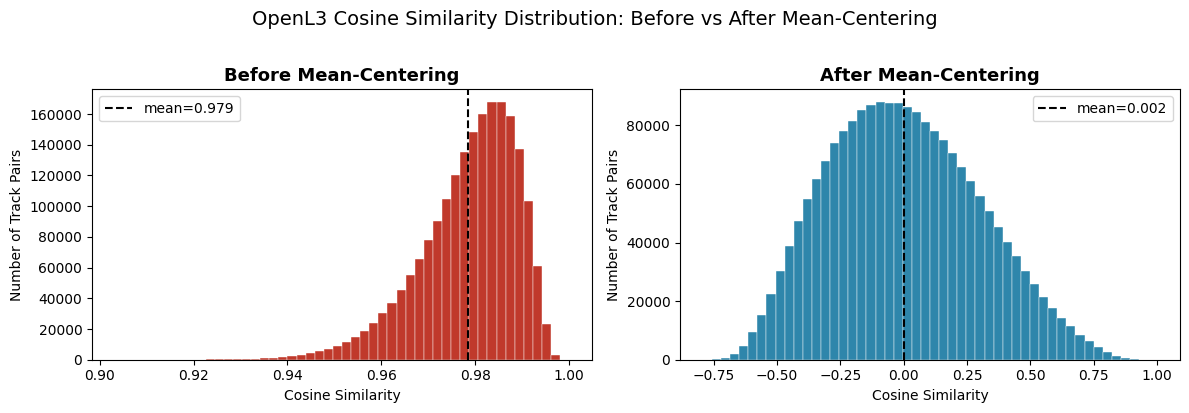


Plot saved to Google Drive!


In [4]:
# ============================================================
# STEP 2: Visualize Before vs After Mean-Centering
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# --- Definition ---
print("=" * 60)
print("MEAN-CENTERING DEFINITION:")
print("Subtract the mean vector from all embeddings before")
print("L2 normalization, to remove the DC offset in the")
print("embedding space — making cosine similarity scores")
print("spread meaningfully instead of clustering near 1.0")
print("=" * 60)

# --- Before mean-centering ---
emb_raw = embeddings.copy()
emb_raw_norm = emb_raw / np.linalg.norm(emb_raw, axis=1, keepdims=True)
sim_before = emb_raw_norm @ emb_raw_norm.T

# --- After mean-centering ---
emb_centered = embeddings - embeddings.mean(axis=0)
emb_centered_norm = emb_centered / np.linalg.norm(emb_centered, axis=1, keepdims=True)
sim_after = emb_centered_norm @ emb_centered_norm.T

# --- Get upper triangle (unique pairs only, exclude self-similarity) ---
idx = np.triu_indices(len(embeddings), k=1)
scores_before = sim_before[idx]
scores_after  = sim_after[idx]

print(f"\nBefore — mean: {scores_before.mean():.3f}, std: {scores_before.std():.3f}")
print(f"After  — mean: {scores_after.mean():.3f}, std: {scores_after.std():.3f}")

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(scores_before, bins=50, color='#C0392B', edgecolor='white', linewidth=0.3)
ax1.set_title('Before Mean-Centering', fontsize=13, fontweight='bold')
ax1.set_xlabel('Cosine Similarity')
ax1.set_ylabel('Number of Track Pairs')
ax1.axvline(scores_before.mean(), color='black', linestyle='--', label=f'mean={scores_before.mean():.3f}')
ax1.legend()

ax2.hist(scores_after, bins=50, color='#2E86AB', edgecolor='white', linewidth=0.3)
ax2.set_title('After Mean-Centering', fontsize=13, fontweight='bold')
ax2.set_xlabel('Cosine Similarity')
ax2.set_ylabel('Number of Track Pairs')
ax2.axvline(scores_after.mean(), color='black', linestyle='--', label=f'mean={scores_after.mean():.3f}')
ax2.legend()

plt.suptitle('OpenL3 Cosine Similarity Distribution: Before vs After Mean-Centering',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/openl3_mean_centering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved to Google Drive!")